<a href="https://colab.research.google.com/github/hehoha3/TensorFlow_tutorial/blob/dev/2_Neural_Network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Giới thiệu
Một vấn đề phân loại liên quan đến việc dự đoán liệu một thứ là thứ này hay thứ khác. Ví dụ:
- Dự đoán một người có mắc bệnh tim hay không dựa trên các thông số sức khỏe của họ. Phương pháp này được gọi là phân loại nhị phân vì chỉ có hai lựa chọn.
- Quyết định xem ảnh chụp là ảnh đồ ăn, ảnh người hay ảnh chó. Phương pháp này được gọi là phân loại đa lớp vì có nhiều hơn hai lựa chọn.
- Dự đoán danh mục nào nên được gán cho một bài viết trên Wikipedia. Phương pháp này được gọi là phân loại đa nhãn vì một bài viết có thể được gán nhiều danh mục.

# Kiến trúc của mô hình phân loại
Mô hình phân loại có kiến trúc rất đa dạng. Bởi vì kiến trúc của nó thay đổi tùy thuộc vào vấn đề mà ta đang giải quyết.

Tuy nhiên nó vẫn luôn chứa:
- input layer
- một số hidden layer
- output layer

Sau đây là một số giá trị chuẩn mà ta thường sử dụng trong mạng nơ-ron phân loại nhị phân và đa lớp:
| Siêu tham số | Binary Classification | Multiclass classification |
|-------|-------|-------|
| Input layer shape | Nó là số lượng features | Giống `binary classification` |
| Hidden layer(s) | Tùy từng vấn đề cụ thể, tối thiểu là 1 và tối đa không giới hạn | Giống `binary classification` |
| Nearons trên mỗi hidden layer | Tùy từng vấn đề cụ thể, tối thiểu là 10 và tối đa 100 | Giống `binary classification` |
| Output layer shape | 1 (*1 lớp trong 2 lớp*) | 1 (*1 lớp trong nhiều lớp*) |
| Hidden activation | Thông thường là [ReLU](https://www.kaggle.com/code/dansbecker/rectified-linear-units-relu-in-deep-learning) (*rectified linear unit - đơn vị tuyến tính chỉnh lưu*) | Giống `binary classification` |
| Output activation | Sigmoid | Softmax |
| Loss function | `Cross entropy` (*[tf.keras.losses.BinaryCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy) trong TensorFlow*) | `Cross entropy` (*[tf.keras.losses.CategoricalCrossentropy](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy) trong TensorFlow*) |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) | Giống `binary classification` |

>Đọc sách [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow](https://drive.google.com/file/d/1ltF3vxXGuNPeo5P-aVEyk6v9oRMrpViB/view) từ trang 295

In [ ]:
import tensorflow as tf
import datetime

print(tf.__version__)
print(f"This cell run at: {datetime.datetime.now()}")

2.19.0
This cell run at: 2025-09-06 03:38:21.383316


# Tạo dữ liệu để xem và fit
Ta có thể bắt đầu bằng cách import 1 tập dữ liệu phân loại nhưng hãy thực hành tạo 1 số dữ liệu phân loại của riêng mình.

> Hãy xem nó như 1 thí nghiệm đơn giản trước khi ta bước vào các thí nghiệm thực tế và chuyên sâu hơn

Để thực hiện điều đó, ta sẽ sử dụng hàm `make_circle()`

In [ ]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

Vậy là ta đã tạo xong 2 dữ liệu X, y cho mô hình, ta hãy xem chúng trông như thế nào

In [ ]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [ ]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

> 🔑 Lưu ý: Một bước quan trọng khi bắt đầu bất kỳ dự án AI nào là quan sát dữ liệu. Và một trong những cách tốt nhất để làm điều này là trực quan hóa dữ liệu ta đang làm việc càng nhiều càng tốt.

In [ ]:
import pandas as pd

circle = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})
circle.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


Ok vậy ta biết được với mỗi 2 biến X sẽ tương ứng với 1 biến y phân loại

Nhưng biến phân loại (*label*) này biểu thị cho điều gì ?
- OK nhưng vì ta chỉ đang sử dụng `head()` để hiển thị được 5 row đầu tiên, nên ta sẽ muốn biết label có bao nhiều class và chúng có bao nhiêu
- Sau đó chúng ta sẽ biểu đồ hóa chúng để xem coi thực sự chúng biểu thị cho điều gì

In [ ]:
circle["label"].value_counts()

,count
label,
1,500
0,500


Vậy là label của ta chỉ có 2 class mà thôi => đây là vấn đề nhị phân (*binary*)

Và mỗi class chứa 500 instance.

Bây giờ ta sẽ xem coi chúng biểu thị cho điều gì.

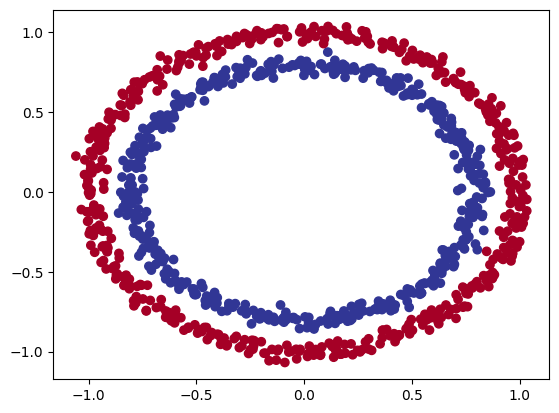

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

Từ biểu đồ trên, ta biết được các label class đại diện cho hình tròn bên trong hoặc bên ngoài, và công việc của mô hình sẽ là phân loại xem dữ liệu mà ta đưa vào nó sẽ nằm trong hình tròn nào.

> Từ đây ta có thể suy nghĩ xem mô hình của ta sẽ trông như thế nào để có thể phân loại được vấn đề này

Ta có thể chơi thử [tensorflow playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=2,2&seed=0.93799&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=true&regularizationRate_hide=true&batchSize_hide=true) để xem coi cách hình thành 1 mô hình
# Input shape và output shapes
Như đã đề cập ở bài trước, một trong những vấn đề mà ta sẽ gặp phải trong quá trình xây dựng mô hình là sự không khớp đối với input shape và output shape.

Bây giờ, việc đầu tiên là ta sẽ kiểm tra shape của X và y của ta

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

Hãy tiếp tục kiểm tra 1 instance của cả 2 biến `X`, `y`

In [ ]:
X[0], y[0]

(array([0.75424625, 0.23148074]), np.int64(1))

Từ đó ta nhận ra là ta có 2 features ở `X` sẽ đưa tới 1 giá trị `y`.

Điều này có nghĩa là input shape của ta sẽ phải chấp nhận 1 tensor có ít nhất một chiều là 2 và đầu ra là 1 tensor có ít nhất 1 giá trị.

> **Lưu ý**: việc y có shape `(1000,)` có thể gây nhầm lẫn. Tuy nhiên, điều này là do tất cả các giá trị y thực chất đều là số vô hướng (*scalar*) và do đó không có chiều.
>
> Hiện tại, hãy coi output shape của ta ít nhất phải cùng giá trị với một example về y (*trong trường hợp của ta, đầu ra từ mạng nơ-ron phải có ít nhất một giá trị*).

# Các bước trong mô hình hóa
Trong TensorFlow thường có 3 bước cơ bản để tạo và đào tạo một mô hình:
1. Create a model - xây dựng các layer cho mô hình
2. Compile a model - xác định cách đo lường hiệu suất bằng `loss` và `metric` và xác định cách cải thiện bằng `optimizer`
3. fitting a model - cho mô hình tìm ra các patterns trong dữ liệu

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# compile a model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# fit a model
model_1.fit(X, y, epochs=5)

Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4385 - loss: 5.2595
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5482 - loss: 5.6005
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5628 - loss: 4.9962
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5291 - loss: 5.1795
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5307 - loss: 4.8776


Với số liệu trên, với accuracy là 50% (*độ chính xác 50%*) đối với 1 bài toán nhị phân thì chẳng khác nào là mô hình ta đang đoán mò.

Nhưng điều gì sẽ xảy ra nếu ta đào tạo mô hình với thời gian lâu hơn

In [ ]:
model_1.fit(X, y, epochs=200, verbose=0)
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4955 - loss: 8.1322   


[8.059046745300293, 0.5]

Tuy đã tăng thời lượng đào tạo lên nhưng mô hình của ta vẫn không có tiến triển gì.

Sẽ thế nào nếu ta thêm 1 layer nữa và tăng thời lượng đào tạo.

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# compile a model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# fit a model
model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5045 - loss: 7.8989  


[7.971191883087158, 0.5]

Vẫn không có quá nhiều tiến triển, accuracy của nó vẫn xấp xỷ 50%
# Cải thiện mô hình
Để có thể cải thiện mô hình, ta sẽ thay thế toàn bộ xử lý của 3 bước xây mô hình trước:
1. Create a model - ta sẽ muốn thêm layer, hidden units trong mỗi layer và thay đổi activation func của mỗi layer
2. Compile a model - ta có thể muốn chọn 1 optimizer khác (*chẳng hạn như  Adam, thường khá tốt cho nhiều vấn đề*) hoặc có thể thay đổi `learning reate` của optimizer.
3. Fitting a model - ta sẽ muốn thêm epochs để quá trình đạo tạo diễn ra lâu hơn

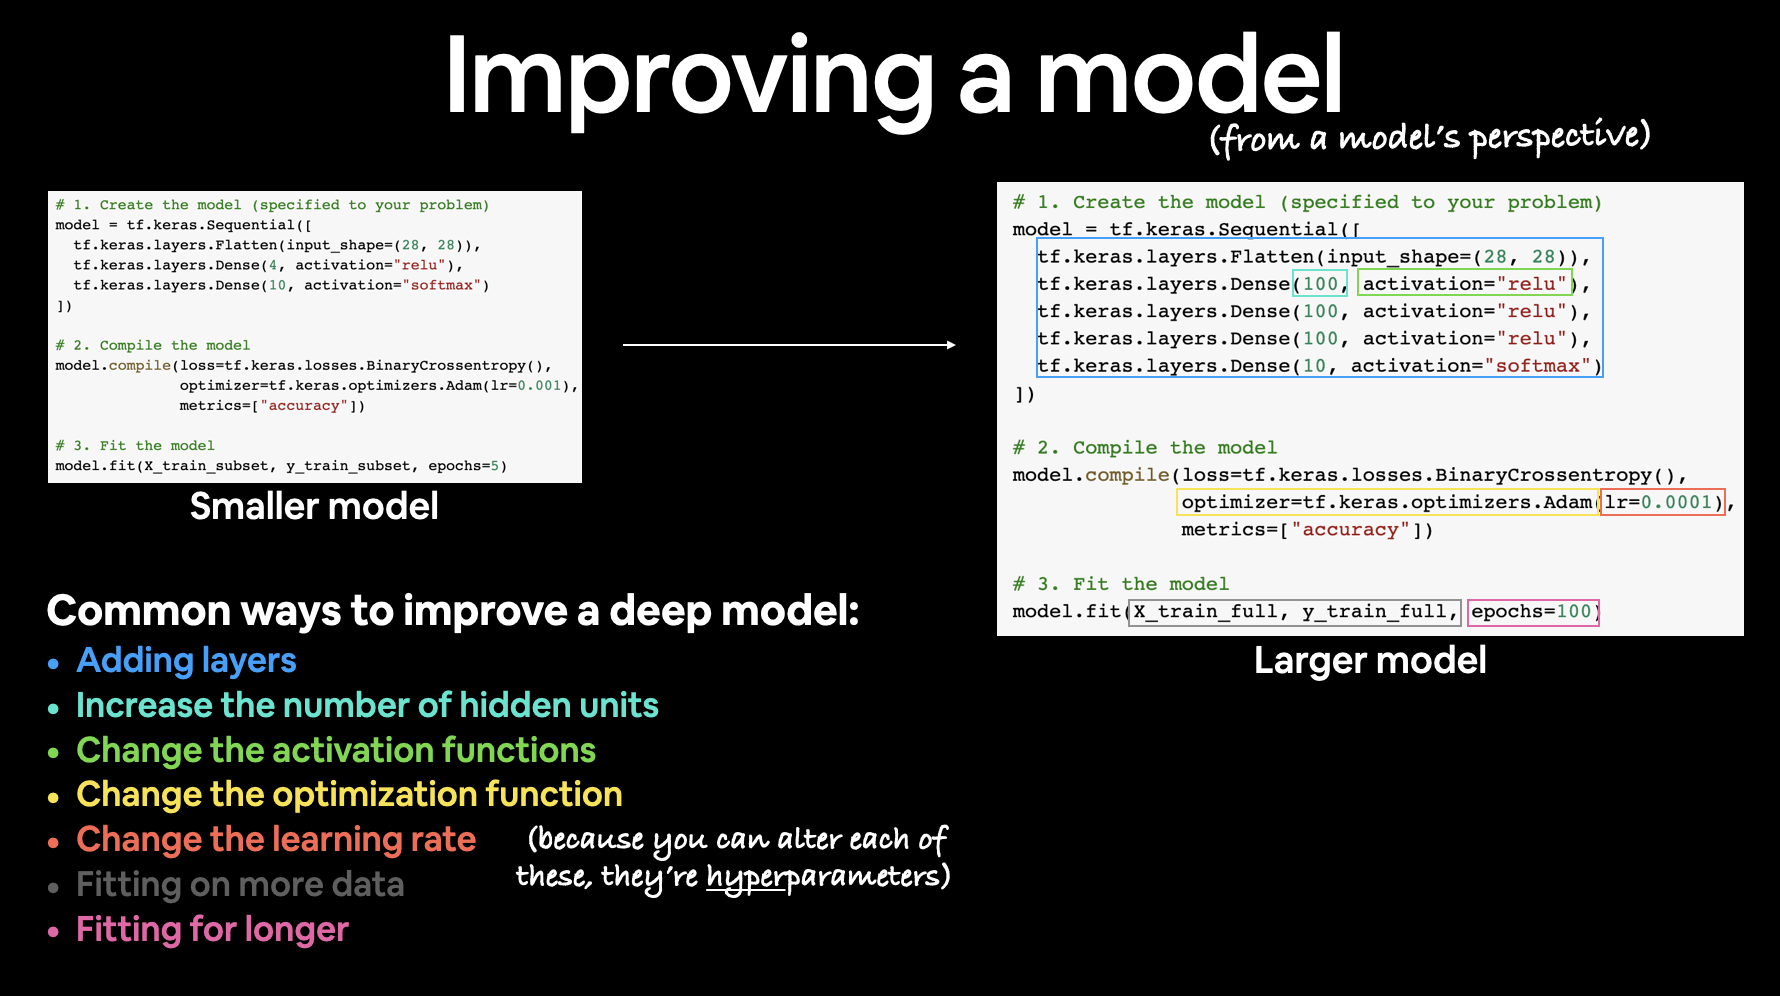

Ta sẽ thử thêm nhiều Neauron hơn, tăng số lượng layer và thay đổi optimizer thành `Adam`

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# compile a model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# fit a model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4570 - loss: 3.9184
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4706 - loss: 0.7369
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4482 - loss: 0.7067
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4322 - loss: 0.6954
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4525 - loss: 0.6956
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4537 - loss: 0.6961
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4520 - loss: 0.6963
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4522 - loss: 0.6966
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4524 - loss: 0.6969
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4534 - loss: 0.6972
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4508 - loss: 0.6974
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

Kết quả là vẫn vậy, mô hình của ta vẫn đang chỉ đoán label với accuracy xấp xỉ 50%.

Ta cần phải hiển thị nó ra để xem coi nó đang trông như thế nào.

> 🔑 **Lưu ý**: Bất cứ khi nào mô hình của ta hoạt động bất thường hoặc có điều gì đó không chắc chắn đang diễn ra với dữ liệu, hãy nhớ rằng **Hiển thị là điều rất tốt để hình dung ra vấn đề**. Kiểm tra dữ liệu, kiểm tra mô hình, và kiểm tra các dự đoán của mô hình.

Để trực quan hóa các dự đoán của mô hình, ta sẽ tạo hàm `plot_decision_boundary()`:
- Có các tham số là mô hình đã được đào tạo, các features (*X*) và label (*y*).
- Tạo [`meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) (*lưới giá trị)* X khác nhau.
- Đưa ra dự đoán trên toàn bộ `meshgrid`.
- Vẽ biểu đồ các dự đoán cũng như đường thẳng giữa các vùng khác nhau (*nơi mỗi class riêng biệt nằm*).

Bây giờ để hiểu rõ trông nó sẽ như thế nào, ta hãy thực hiện nó.

In [ ]:
import numpy as np

def plot_decision_boundary(model, X, y):
  # Define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                       np.linspace(y_min, y_max, 100))

  # Create X values
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions using the trained model
  y_pred = model.predict(x_in)

  # Check for multi-class
  # We have to reshape our predictions to get them ready for plotting
  if model.output_shape[-1] > 1:
    print("doing multiclass classification...")
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classifcation...")
    y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)

  # Plot decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

Bây giờ ta có một hàm để vẽ ranh giới quyết định của mô hình (*phân chia giữa các chấm đỏ và xanh*), hãy thử xem.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


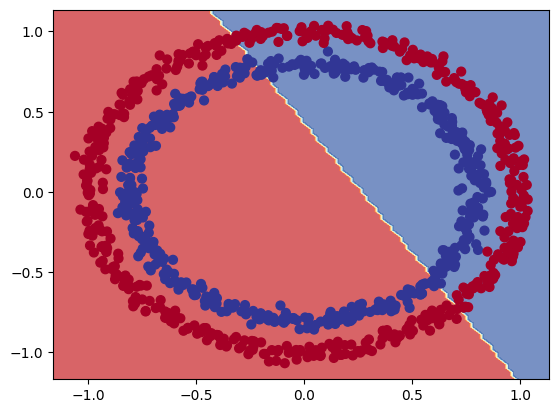

In [ ]:
plot_decision_boundary(model_3, X, y)

Có vẻ như mô hình của ta đang cố gắng vẽ 1 đường thẳng tuyến tính qua dữ liệu.

Vấn đề là dữ liệu của ta không thể phân tách bằng 1 đường thẳng

Qua biểu đồ, ta biết được mô hình của ta đang đoán mò với xu hướng phân tách dữ liệu ra 2 phần thông qua 1 đường thẳng tuyến tính.

# Sự phi tuyến tính
Nếu ta muốn mô hình hóa dữ liệu phân loại, ta sẽ cần một số layer phi tuyến tính.

> Trước khi bắt đầu hãy chơi với [TensorFlow Playground](https://playground.tensorflow.org/#activation=linear&batchSize=1&dataset=circle&regDataset=reg-plane&learningRate=0.01&regularizationRate=0&noise=0&networkShape=1&seed=0.09561&showTestData=false&discretize=false&percTrainData=70&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularizationRate_hide=true&discretize_hide=true&regularization_hide=true&dataset_hide=true&noise_hide=true&batchSize_hide=true), hãy thử thay đổi Activation của nó và thay đổi về các layer để xem dự đoán của nó về dữ liệu có gì khác biệt.

Thay đổi chính mà ta sẽ thêm vào các mô hình đã xây dựng trước đó là việc sử dụng từ khóa `activation`.

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_4 = tf.keras.Sequential([
  tf.keras.layers.Dense(1, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(1) # output layer
])

# compile a model
model_4.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# fit a model
model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4591 - loss: 4.7707
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4581 - loss: 3.8792 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4581 - loss: 3.7689
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4581 - loss: 3.7048
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4581 - loss: 3.6571
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4581 - loss: 3.6126
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4576 - loss: 3.5776
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4577 - loss: 3.5713
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4577 - loss: 3.5552
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4583 - loss: 3.5399 
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4583 - loss: 3.5259 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accura

Có vẻ như nó vẫn đang chưa học được gì, vì hiện activation đang là 50%.

Khi thực hiện trên `Tensorflow playground`, ta thấy khi thực hiện với activation `ReLU` nó có thể dự đoán khá tốt nếu ta có 2 hidden layer với layer đầu tiên có 3 hidden unit và layer thứ 2 có 2 hidden unit.

Nhưng ta sẽ tăng số lưởng hidden unit ở mỗi layer lên để đảm bảo mô hình luôn có 1 dự đoán chính xác nhất.
- Cùng với đó, ta sẽ sử dụng thêm tham số `learning_rate` cho `optimizer`

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_5 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(1)
])

# compile a model
model_5.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# fit a model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4228 - loss: 1.7934
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4471 - loss: 0.7643
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5104 - loss: 0.6997
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5873 - loss: 0.6718
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6499 - loss: 0.6539
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6714 - loss: 0.6304
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6875 - loss: 0.6100
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7074 - loss: 0.5789
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7573 - loss: 0.5337
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8579 - loss: 0.4451
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8784 - loss: 0.3516
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

Accuracy của mô hình vẫn xấp xỉ 50%, ta hãy hiển thị mô hình hiện tại ra để xem coi nó đang gặp vấn đề gì.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


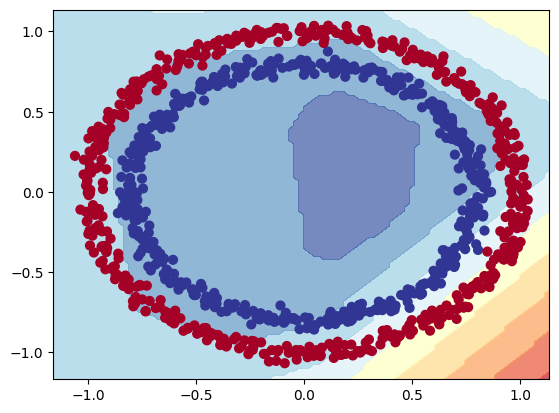

In [ ]:
plot_decision_boundary(model_5, X, y)

Mô hình của ta tuy đã giống với mô hình trong `TensorFlow Playground` nhưng nó vẫn chưa thể dự đoán đủ tốt.

Lần này ta cũng sẽ thay đổi activation trên output layer. Ta còn nhớ kiến
trúc của một mô hình phân loại chứ? Đối với phân loại nhị phân, activation output layer thường là `Sigmoid`.


In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_6 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

# compile a model
model_6.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=['accuracy'])

history_2 = model_6.fit(X, y, epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4941 - loss: 0.7046
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4775 - loss: 0.6907
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5295 - loss: 0.6834 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5696 - loss: 0.6738
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6084 - loss: 0.6605
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6431 - loss: 0.6410
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6698 - loss: 0.6044
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7606 - loss: 0.5574
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7845 - loss: 0.4997
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8296 - loss: 0.4495
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8671 - loss: 0.4139
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

Yes sir, bây giờ đúng là mô hình của ta đã học được cái gì đó.

Hãy thử đưa nó vào đánh giá và hiển thị nó ra xem hiện tại nó đang trông như thế nào

In [ ]:
model_6.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9959 - loss: 0.0102  


[0.009485241025686264, 0.996999979019165]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


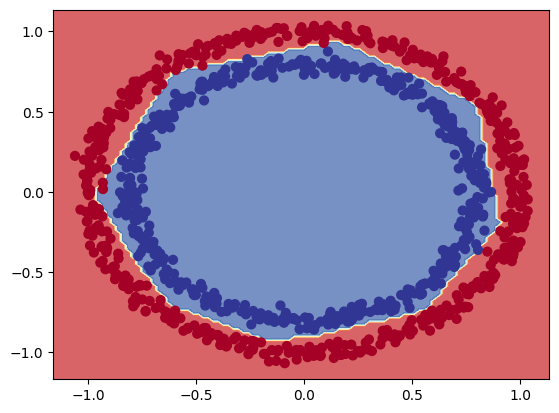

In [ ]:
plot_decision_boundary(model_6, X, y)

> 🔑 **Lưu ý**: Sự kết hợp giữa hàm tuyến tính và hàm phi tuyến tính là một trong những nguyên tắc cơ bản của mạng nơ-ron.

Nếu ta có 1 số lượng không giới hạn các đường thẳng và đường không thẳng, thì ta có thể vẽ được những kiểu mô hình như thế nào ?

Để có thể quan sát được các hàm tuyến tính và phi tuyến tính có thể thực hiện được những gì, hãy thử ví dụ như sau:

In [ ]:
A = tf.cast(tf.range(-10, 10), tf.float32)
A

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

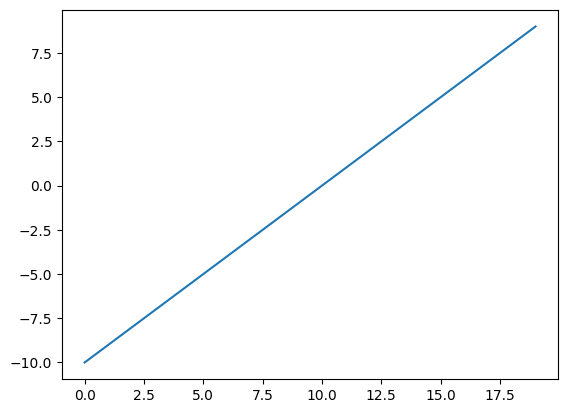

In [ ]:
plt.plot(A)

Dữ liệu ví dụ mà ta vừa tạo ra 1 dữ liệu tuyến tính (*được hiển thị như 1 đường thẳng*)

Tốt, giờ ta hãy tạo lại hàm [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) và xem nó ảnh hưởng thế nào đến dữ liệu trên

In [ ]:
def sigmoid(x):
  return 1 / (1 + tf.exp(-x))

sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397872e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726233e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105860e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

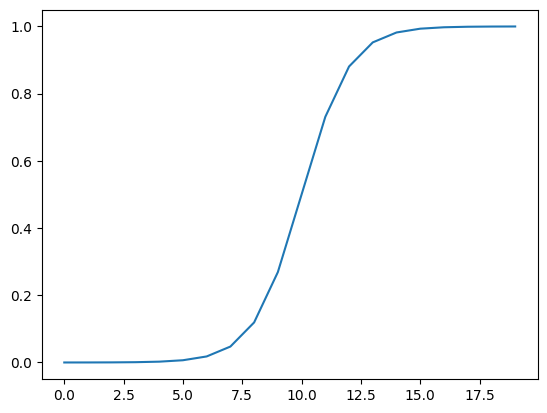

In [ ]:
plt.plot(sigmoid(A))

Khi dữ liệu tuyến tính đi qua hàm sigmoid nó đã trở thành dữ liệu phi tuyến tính

Được rồi, còn hàm [ReLU](https://en.wikipedia.org/wiki/Rectified_linear_unit) thì sao (*ReLU biến tất cả số âm thành 0 và giữ nguyên số dương*)

In [ ]:
def relu(x):
  return tf.maximum(0, x)

relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

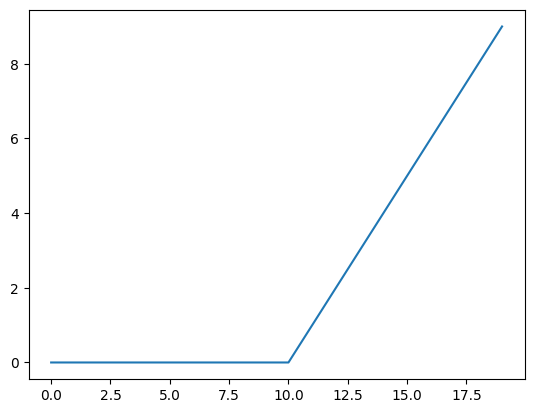

In [ ]:
plt.plot(relu(A))

Ok vậy là ta đã biết về hàm sigmoid cũng như hàm relu, vậy còn [hàm linear activation](https://www.tensorflow.org/api_docs/python/tf/keras/activations/linear) của Tensorflow thì sao

In [ ]:
tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.],
      dtype=float32)>

Nhìn có vẻ như input của ta không dược thay đổi gì hết.

In [ ]:
A == tf.keras.activations.linear(A)

<tf.Tensor: shape=(20,), dtype=bool, numpy=
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])>

Được rồi, vậy là hợp lý khi mô hình không thực sự học được bất cứ điều gì khi chỉ sử dụng các hàm linear activation, vì hàm linear activation không thay đổi dữ liệu input của ta theo bất kỳ cách nào.

Trong khi đó, với các hàm phi tuyến tính, dữ liệu của ta bị thay đổi. Mạng nơ-ron sử dụng những phép biến đổi này ở quy mô lớn để tìm ra các mẫu vẽ giữa các input và output của nó.

# Đánh giá và cải thiện mô hình phân loại
Hiện tại ta đang đánh giá mô hình trên cùng dữ liệu mà ta đưa vào nó để đào tạo.

Cách tiếp cận tốt hơn là nên chia dữ liệu thành Training set, Validation set và Test set

Bây giờ ta sẽ thực hiện việc chia dữ liệu và xây dựng lại mô hình của ta trên Training set sau đó thực hiện đánh giá mô hình này trên Test set của mình.

In [ ]:
len(X)

1000

In [ ]:
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[:200], y[:200]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((800, 2), (800,), (200, 2), (200,))

Vậy là ta đã chia dữ liệu xong thành 2 tập là Training set và Test set.

Bây giờ ta sẽ thực hiện việc xây dựng mô hình trên training set

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_7 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
  tf.keras.layers.Dense(1, activation=tf.keras.activations.sigmoid)
])

# compile a model
model_7.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# fit a model
history_3 = model_7.fit(X_train, y_train, epochs=100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5129 - loss: 0.7068
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5001 - loss: 0.6932
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5135 - loss: 0.6891
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5418 - loss: 0.6846
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5527 - loss: 0.6793 
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5991 - loss: 0.6715 
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6342 - loss: 0.6578 
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6505 - loss: 0.6390 
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6779 - loss: 0.6152 
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7316 - loss: 0.5799 
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7941 - loss: 0.5338 
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

In [ ]:
model_7.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0054  


[0.004278475418686867, 1.0]

Với model này ta có accuracy gần bằng 100% và có khi lên tới 100%.

> **Gợi ý thêm**
>
> - Trong tensorflow, tại các activation function, ta có thể định nghĩa func mà nó sử dụng bằng string.
>   - Ví dụ: `"relu"` thay vì `tf.keras.activations.relu` và `"sigmoid"` thay vì `tf.keras.activations.sigmoid`

Giờ là lúc ta trực quan hóa mô hình mới này của ta trên cả Training set và Test set

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


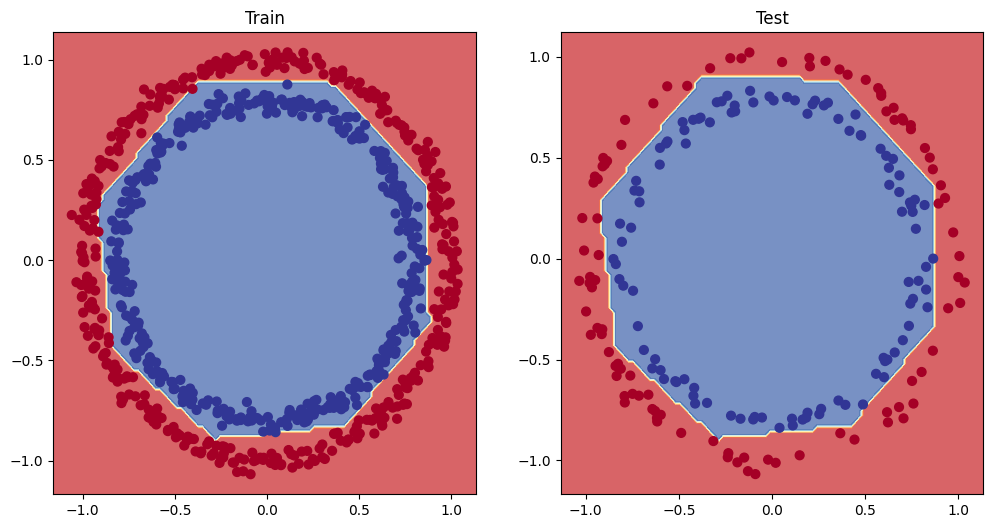

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_7, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_7, X_test, y_test)
plt.show()

## Vẽ biểu đồ `loss`
Nhìn vào biểu đồ trên ta có thể thấy được kết quả đầu ra của mô hình là rất tốt

Nhưng mô hình của ta hoạt động thế nào trong quá trình học? Hiệu suất dự đoán của nó thay đổi như thế nào trong quá trình này.

Để tìm hiểu điều này, ta sẽ muốn vẽ ra biểu đồ `loss` (*còn gọi là biểu đồ đường cong học tập*)

Hãy nhớ rằng, khi sử dụng `fit()` ta cũng tạo ra 1 biến `history` - đây là nơi mà ta sẽ nhận được thông tin hiệu suất của mô hình trong quá trình học.

In [ ]:
pd.DataFrame(history_3.history)

,accuracy,loss
0,0.50000,0.700090
1,0.48875,0.693118
2,0.50500,0.689508
3,0.52500,0.685880
4,0.53375,0.681135
...,...,...
95,0.99875,0.008568
96,0.99875,0.008612
97,0.99875,0.008667
98,0.99875,0.008712


Từ bảng trên ta có thể thấy hiệu suất của mô hình được cải tiến rõ rệt qua từng `epoch`.

Accuracy từ 50% tới 99% và loss từ 0.7 xuống còn 0.008

Bây giờ là lúc ta vẽ nó ra để xem coi sự thay đổi thế nào.

Text(0.5, 1.0, 'Model 8 training curves')

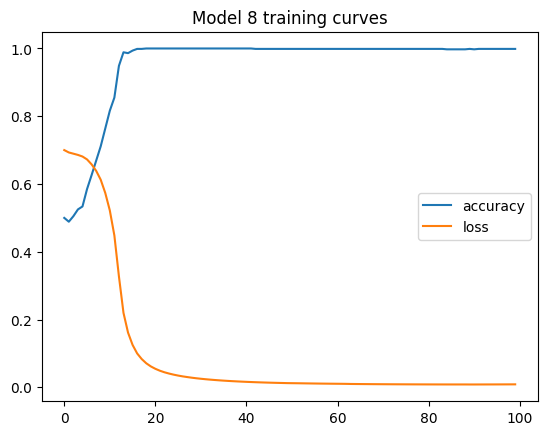

In [ ]:
pd.DataFrame(history_3.history).plot()
plt.title("Model 8 training curves")

Tuyệt vời. Đây là sơ đồ lý tưởng mà ta sẽ trông chờ khi giải quyết vấn đề phân loại, là `loss` sẽ giảm xuống và `accuracy` sẽ tăng lên

## Tìm kiếm `learning rate` tốt nhất
Ngoài bản thân kiến trúc của mô hình (*các layer, hidden units, activation func, ...*) thì có 1 siêu tham số cũng đóng vai trò quan trọng đó là `learning rate`

Như ở các mô hình mà ta vừa xây dựng, ta đang sử dụng learning rate là 0.01. Và ta có thể thay đổi nó thành 1 số khác.

Vì sao lại như vậy ?
  - Về cơ bản, khi xây dựng 1 mô hình AI ta có thể thay đổi các siêu tham số tùy ý của mình.
  - Ta sẽ thực hiện xây dựng nó với tham số này, đánh giá nó, và xây dựng nó với 1 tham số khác và tiếp tục đánh giá, và việc này sẽ diễn ra cho tới khi ta nhận được 1 mô hình ta cho là tốt nhất đối với bài toán của mình.

Learning rate cũng vậy, nó không quy định 1 giá trị nào là tốt nhất.

Ta sẽ phải thử nghiệm nó với mô hình để tìm coi giá trị nào là phù hợp với mô hình cho bài toán mà ta đang gặp phải.

Nhưng ta sẽ có 1 số mẹo để giúp ta tìm được giá trị learning rate tốt nhất 1 cách nhanh hơn:
- Sử dụng [learning rate callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/LearningRateScheduler)
- Sử dụng 1 biểu đồ loss để đánh giá

Dưới đây ta sẽ tạo 1 `learning rate schedule callback` để duyệt qua 1 tập hợp các giá trị learning rate bắt đầu từ `1e-4` và sẽ tăng thêm `10^(epoch/20)` ở mỗi epoch

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_8 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile a model
model_8.compile(loss="binary_crossentropy",
                optimizer="Adam",
                metrics=["accuracy"])

# create a learning rate schedule callback
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-4 * 10**(epoch/20))

# fit a model
history_4 = model_8.fit(X_train, y_train, epochs=100, callbacks=[lr_schedule])

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5170 - loss: 0.7157 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5189 - loss: 0.7150 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5129 - loss: 0.7142 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5152 - loss: 0.7133 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5127 - loss: 0.7124 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5153 - loss: 0.7115 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5151 - loss: 0.7105 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5139 - loss: 0.7094 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5208 - loss: 0.7084 - learning_

Bây giờ mô hình của ta đã hoàn tất quá trình đào tạo, hãy cùng xem `history` của nó

<Axes: >

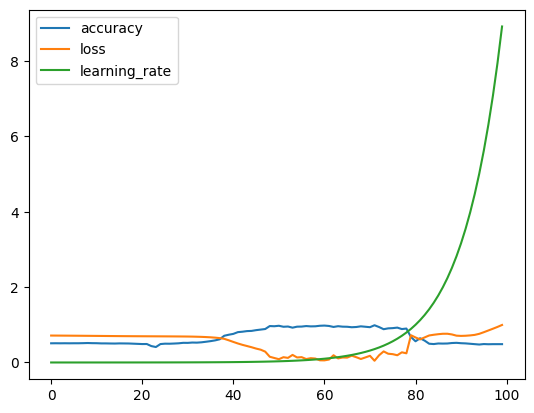

In [ ]:
pd.DataFrame(history_4.history).plot()

Learning rate tăng theo cấp số nhân khi số epoch tăng.

Và ta có thể thấy accuracy của mô hình tăng lên và loss của nó giảm xuống tại một thời điểm cụ thể khi learning rate tăng dần.

Để nhìn ra được sự ảnh hưởng này ta có thể vẽ biểu đồ cho loss và learning rate

Text(0.5, 1.0, 'Learing rate & Loss')

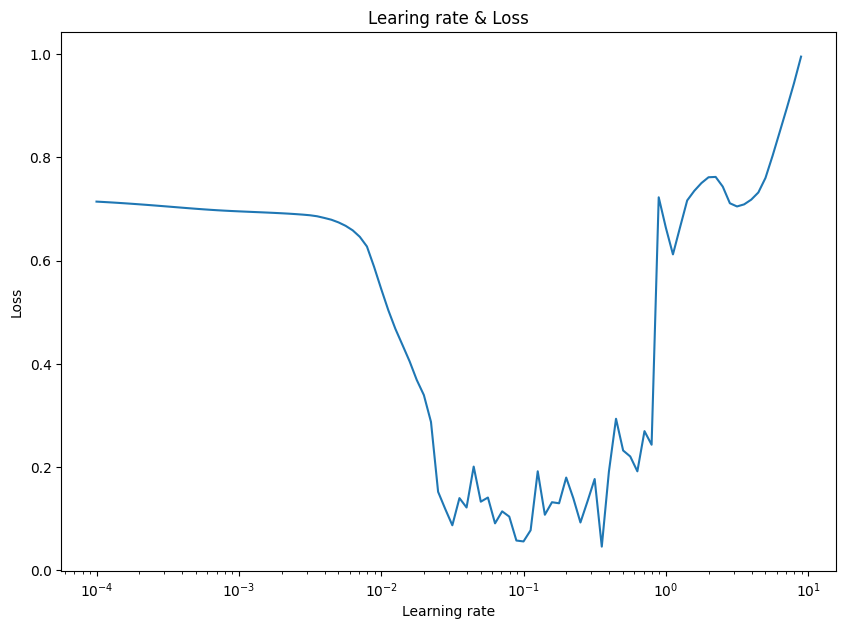

In [ ]:
lrs = 1e-4 * (10 ** (np.arange(100)/20))

plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history_4.history["loss"])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Learing rate & Loss")

Ta sẽ lấy giá trị learning rate mà tại đó giá trị los là thấp nhất

Ở đây ta có thể nhận thấy rằng tại learning rate khoảng từ `10^-1.5` tới `10^-0.5` là có giá trị loss thấp nhất.

Nhưng sẽ có các giá trị thông thường sẽ được sử dụng nhiều, đó có thể là: `1`, `0.1`, `0.01`, `0.001`, `0.0001`

Tại biểu đồ trên ta có thể nhận thấy giá trị learning rate khiến loss thấp nhất nằm ở khoảng `10^-1.5` xấp xỉ `0.03` và ta sẽ thử sử dụng nó trên mô hình

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_9 = tf.keras.Sequential([
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(1, activation="sigmoid")
])

# compile a model
model_9.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.03),
                metrics=["accuracy"])

# fit a model
model_9.fit(X_train, y_train, epochs=20)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4989 - loss: 0.7039
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5604 - loss: 0.6847
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5951 - loss: 0.6638 
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6897 - loss: 0.6021 
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8468 - loss: 0.4646 
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9755 - loss: 0.2195 
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9879 - loss: 0.1183 
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0800 
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9798 - loss: 0.0686 
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9878 - loss: 0.0524 
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9839 - loss: 0.0473
Epoch 12/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9

Ta đã sử dụng learning rate là 0.03 với số epochs chỉ là 20 nhưng kết quả mà ta nhận được thì lại rất tốt.

In [ ]:
model_9.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9881 - loss: 0.0394  


[0.03204149380326271, 0.9900000095367432]

Giá trị khi nó thực hiện dự đoán trên Test set là rất tốt. Hãy thử trực quan hóa nó để xem coi nó trông thế nào.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


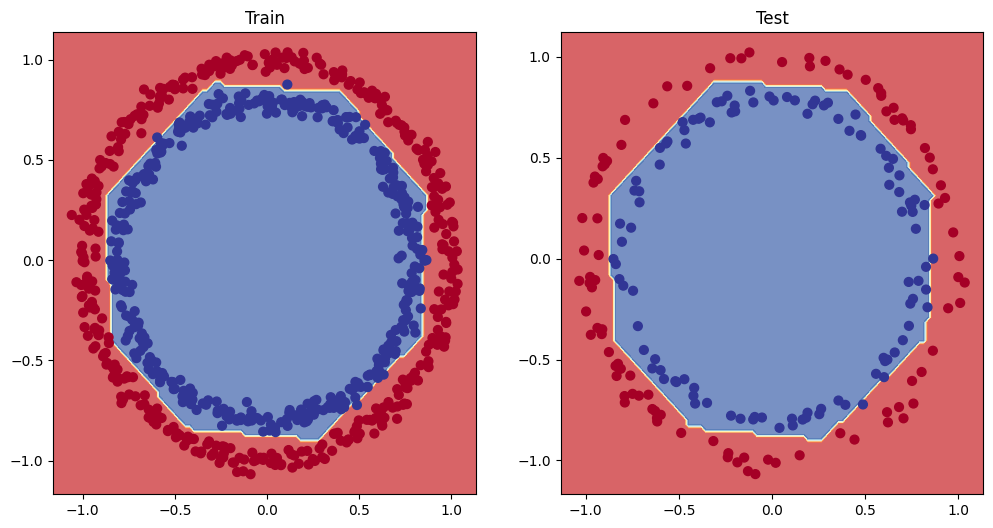

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_9, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_9, X_test, y_test)

Tóm lại, ta hãy tổng kết lại quá trình tìm kiếm các tham số cho mô hình:
1. Đầu tiên là hãy sử dụng các giá trị mặc định của các tham số để xem chúng hoạt động như thế nào
2. Nếu nó không hoạt động tốt như ý của ta, hãy bắt đầu thay đổi các tham số đó từng cái 1, hoặc kết hợp sự thay của chúng và tìm ra mô hình hoạt động tốt nhất.

# Các phương pháp đánh giá mô hình khác
Bên cạnh các hình ảnh trực quan mà ta đã thực hiện, còn có một số số liệu đánh giá khác nhau mà ta có thể sử dụng để đánh giá các mô hình phân loại của mình.

| Metric / Evaluation method | Định nghĩa | Code |
|-------|-------|-------|
| Accuracy     | Trong số 100 dự đoán, mô hình của ta dự đoán chính xác bao nhiêu? *Ví dụ: Độ chính xác 95% nghĩa là mô hình dự đoán chính xác 95/100 dự đoán.*     | [`sklearn.metrics.accuracy_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html) hoặc [`tf.keras.metrics.Accuracy()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/Accuracy)     |
| Precision     | Tỷ lệ dương tính thật trên tổng số mẫu. Độ chính xác cao hơn dẫn đến ít dương tính giả hơn (*tính giả hơn là mô hình dự đoán 1 trong khi đáng lẽ phải là 0*).     | [`sklearn.metrics.precision_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html) hoặc [`tf.keras.metrics.Precision()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/Precision)     |
| Recall     | Tỷ lệ dương tính thật trên tổng số dương tính thật và âm tính giả (*mô hình dự đoán 0 trong khi đáng lẽ phải là 1*). Recall cao hơn dẫn đến ít âm tính giả hơn.     | [`sklearn.metrics.recall_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) hoặc [`tf.keras.metrics.Recall()`](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/Recall)     |
| F1-score     | Kết hợp `precision` và `recall` thành một số liệu. 1 là tốt nhất, 0 là tệ nhất.     | [`sklearn.metrics.f1_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)     |
| [Confusion matrix](https://www.dataschool.io/simple-guide-to-confusion-matrix-terminology/)     | So sánh các giá trị dự đoán với các giá trị thực theo dạng bảng, nếu đúng 100%, tất cả các giá trị trong ma trận sẽ từ trên cùng bên trái xuống dưới cùng bên phải (*dòng chẩn đoán*).     | [`sklearn.metrics.plot_confusion_matrix()`](https://scikit-learn.org/1.1/modules/generated/sklearn.metrics.plot_confusion_matrix.html) hoặc tự tạo function     |
| Classification report     | Bộ sưu tập một số số liệu phân loại chính như `precision`, `recall` và `f1-score`.     | [`sklearn.metrics.classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)     |

Hãy bắt đầu với `Accuracy`. Bởi vì ta đã truyền `["accuracy"]` vào tham số `mretics` khi `compile` mô hình, nên việc gọi `evaluate()` trên mô hình sẽ trả về cả `loss` và `accuracy`

In [ ]:
loss, accuracy = model_9.evaluate(X_test, y_test)

print(f"Model loss in test set: {loss}")
print(f"Model accuracy in test set: {accuracy * 100}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9881 - loss: 0.0394 
Model loss in test set: 0.03204149380326271
Model accuracy in test set: 99.00000095367432%


Thế còn **confusion matrix** (*ma trận nhầm lẫn*) thì sao?

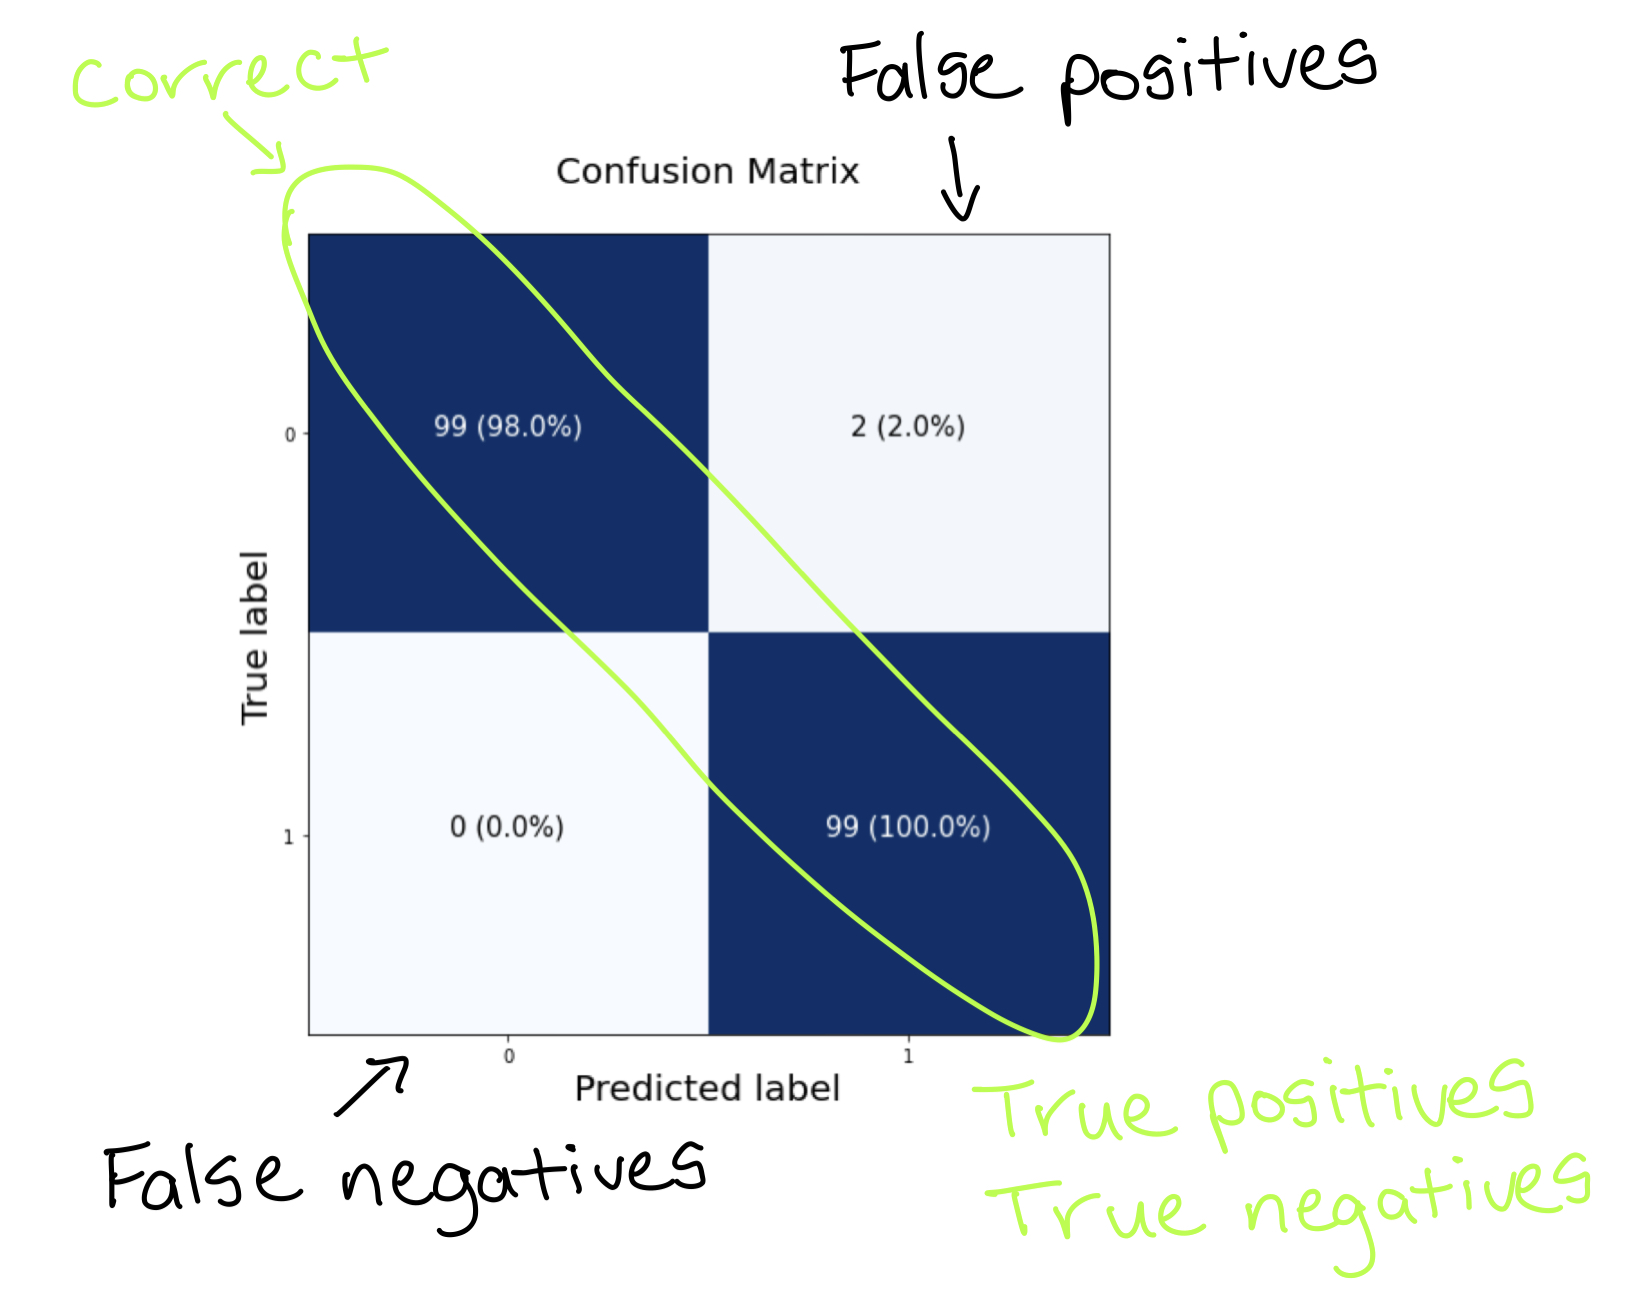

Ta có thể tạo **confusion matrix** bằng hàm `confusion_matrix` của Scikit-Learn.

In [ ]:
# from sklearn.metrics import confusion_matrix

# y_preds = model_9.predict(X_test)
# confusion_matrix(y_test, y_preds)

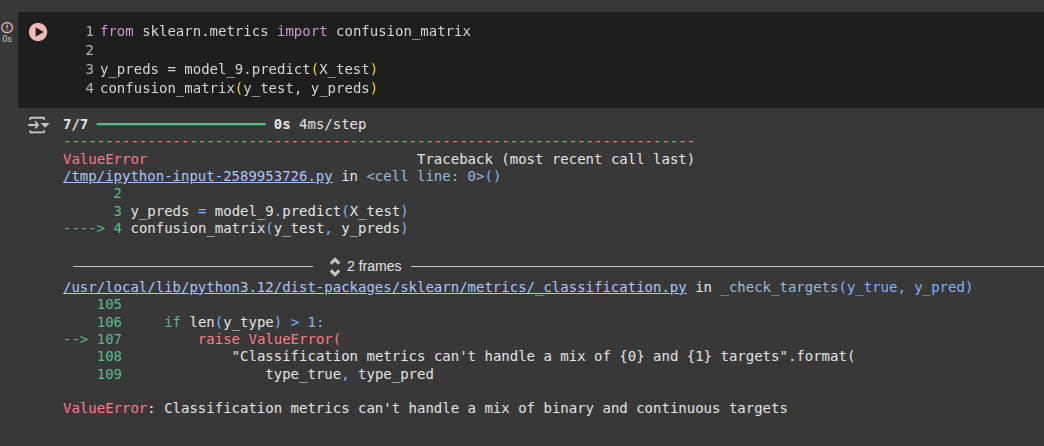

Có vẻ như dự đoán của ta không theo đúng định dạng cần thiết, hãy kiểm tra nó xem

In [ ]:
from sklearn.metrics import confusion_matrix

y_preds = model_9.predict(X_test)
y_preds[:10]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([[9.9975681e-01],
       [9.9966651e-01],
       [9.9464345e-01],
       [9.8974216e-01],
       [3.6059710e-04],
       [8.0099010e-01],
       [9.9665850e-01],
       [9.9957174e-01],
       [9.9890065e-01],
       [8.0397314e-07]], dtype=float32)

In [ ]:
y_test[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

Ta cần đưa các dự đoán của mô hình về dạng nhị phân (*0 và 1*).

Ở định dạng hiện tại chúng đang ở dạng được gọi là **xác suất dự đoán**. Thông thường, chúng không phải là những giá trị chính xác mà là xác suất về khả năng chúng sẽ là một giá trị này hay giá trị khác.

Vì vậy, một trong những bước ta thường thấy sau khi đưa ra dự đoán bằng mạng nơ-ron là chuyển đổi xác suất dự đoán thành label.

Trong trường hợp của ta, vì label thực tế là nhị phân, ta có thể chuyển đổi xác suất dự đoán sử dụng sang dạng nhị phân của chúng bằng cách sử dụng `tf.round()`.

In [ ]:
tf.round(y_preds)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.]], dtype=float32)>

Ok, bây giờ ta sẽ sử dụng nó với `confusion_matrix()`

In [ ]:
confusion_matrix(y_test, tf.round(y_preds))

array([[ 96,   0],
       [  2, 102]])

Qua biểu đồ trên ta thấy được chỉ có 2 giá trị bị dự đoán sai.
- Đúng ra nó nên được dự đoán là 1, nhưng nó đang được dự đoán là 0

Ta cũng có thể tự tạo 1 hàm `confusion_matrix()` để xem xét trực quan hơn

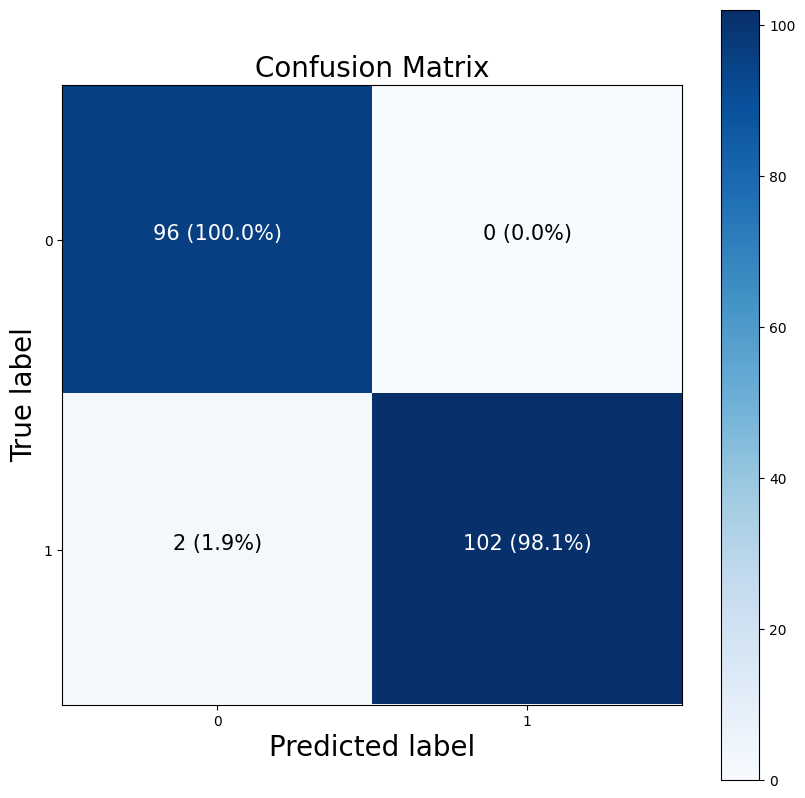

In [ ]:
import itertools

figsize = (10, 10)

# Create the confusion matrix
cm = confusion_matrix(y_test, tf.round(y_preds))
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
n_classes = cm.shape[0]

# Let's prettify it
fig, ax = plt.subplots(figsize=figsize)
# Create a matrix plot
cax = ax.matshow(cm, cmap=plt.cm.Blues) # https://matplotlib.org/3.2.0/api/_as_gen/matplotlib.axes.Axes.matshow.html
fig.colorbar(cax)

# Create classes
classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0])

# Label the axes
ax.set(title="Confusion Matrix",
       xlabel="Predicted label",
       ylabel="True label",
       xticks=np.arange(n_classes),
       yticks=np.arange(n_classes),
       xticklabels=labels,
       yticklabels=labels)

# Set x-axis labels to bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Adjust label size
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
ax.title.set_size(20)

# Set threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
           horizontalalignment="center",
           color="white" if cm[i, j] > threshold else "black",
           size=15)

`itertools.product` có chức năng gì?
- Nó giúp kết hợp hai thứ vào mỗi tổ hợp

In [ ]:
import itertools
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  print(i, j)

0 0
0 1
1 0
1 1


# Phân loại đa lớp (*multiclass classification*)
Bây giờ đã đến lúc ta đi tới 1 bài toán phức tạp hơn đó là phân loại đa lớp.
- Không phải chi có 2 lớp như bài toán phân loại nhị phân, mà nó có nhiều lựa chọn hơn. Ví dụ như phân loại 1 vật là áo phông, quần bò hay đôi giày

Để bắt đầu, ta cần một số dữ liệu. Điều tuyệt vời là TensorFlow có sẵn một bộ dữ liệu phân loại đa lớp được gọi là [`Fashion MNIST`](https://www.tensorflow.org/tutorials/keras/classification).

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(f"Training sample:\n{train_data[0]}\n")
print(f"Training label: {train_labels[0]}")

Training sample:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1  

Ta có một danh sách dài các con số (*data*), và sau đó là một con số duy nhất (*label*).

Vậy còn shape của chúng thì sao ?

In [ ]:
train_data.shape, train_labels.shape, test_data.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
train_data[0].shape, train_labels[0].shape

((28, 28), ())

Vậy ta có 60.000 instance cho training set, mỗi ví dụ có shape `(28, 28)` và 1 label, cũng như 10.000 instance cho test set có shape `(28, 28)`.

Bây giờ hãy hiển thị chúng ra

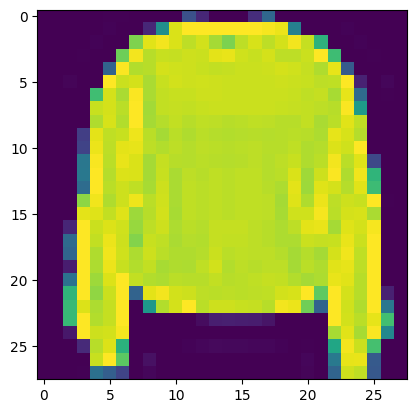

In [ ]:
plt.imshow(train_data[7])

In [ ]:
train_labels[7]

np.uint8(2)

Ta thấy rằng hiện tại label của ta đang ở dạng số, điều này khá tốt khi hoạt động với mô hình, nhưng ta sẽ cần biết nó chính xác là cái gì.

Hãy tạo một list nhỏ các classname (*ta có thể tìm thấy chúng trên [trang GitHub của tập dữ liệu](https://github.com/zalandoresearch/fashion-mnist#labels)*).

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

Vậy là ta đã có 10 class name đại diện cho 10 loại đồ mặc trên người và chúng cũng đại diện cho các number label của ta.

Text(0.5, 1.0, 'Pullover')

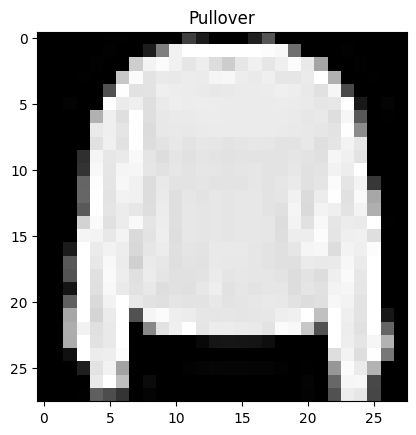

In [ ]:
plt.imshow(train_data[7], cmap="gray")
plt.title(class_names[train_labels[7]])

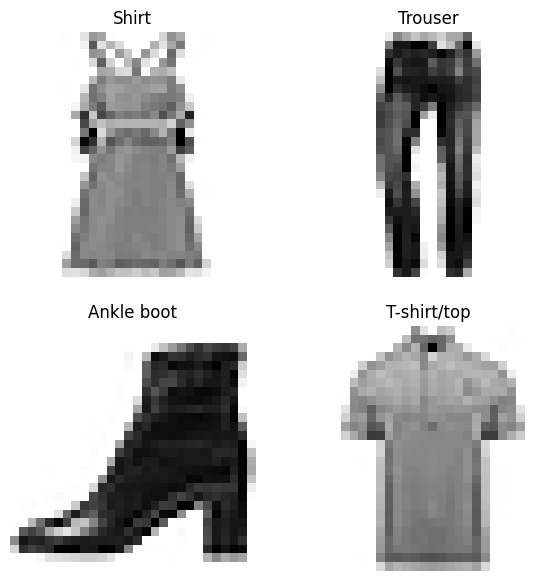

In [ ]:
import random

tf.keras.utils.set_random_seed(42)

plt.figure(figsize=(7, 7))
for i in range(4):
  ax = plt.subplot(2, 2, i + 1)
  rand_index = random.choice(range(len(train_data)))
  plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
  plt.title(class_names[train_labels[rand_index]])
  plt.axis(False)

Bây giờ ta sẽ xây dựng 1 mô hình để tìm ra mối quan hệ giữa các giá trị pixel và label của chúng.

Và vì đây là vấn đề phân loại đa lớp nên ta sẽ có chút thay đổi trong mô hình của mình:
- `input shape` sẽ phải xử lý theo tensor `28x28` (*width và height của ảnh*)
  - Trên thực tế, ta sẽ nén dữ liệu đầu vào thành tensor có dạng vector và  nó có shape `(784)` bằng layer `Flatten()`.
- `output shape` sẽ phải là 10 vì ta cần mô hình dự đoán cho 10 class khác nhau.
  - Ta cũng sẽ thay đổi activation fuc của output layer thành `softmax` thay vì `sigmoid`. Hàm `softmax` sẽ xuất ra một chuỗi các giá trị từ 0 đến 1 (*có cùng shape với shape của output, tổng của chúng xấp xỉ 1*). Mô hình dự đoán chỉ số có giá trị cao nhất là lớp có khả năng xảy ra cao nhất.
- Ta cũng cần thay đổi loss func từ Binary loss func thành Multiclass loss func
  - Cụ thể hơn, vì label của ta ở dạng số nguyên, ta sẽ sử dụng [`tf.keras.losses.SparseCategoricalCrossentropy()`](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy), nếu label của ta được mã hóa one-hot (*ví dụ: chúng trông giống như [0, 0, 1, 0, 0...]*), ta sẽ sử dụng [`tf.keras.losses.CategoricalCrossentropy()`](https://www.tensorflow.org/api_docs/python/tf/keras/losses/CategoricalCrossentropy).
- Ta cũng sẽ sử dụng tham số `validation_data` khi gọi hàm `fit()`. Điều này sẽ cho ta biết mô hình hoạt động thế nào trên Test set trong quá trình huấn luyện

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_10 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

# compile a model
model_10.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(),
                  metrics=["accuracy"])

# fit a model
non_norm_history = model_10.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1252 - loss: 2.5313 - val_accuracy: 0.2861 - val_loss: 1.9579
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3163 - loss: 1.7538 - val_accuracy: 0.3867 - val_loss: 1.5045
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3499 - loss: 1.5287 - val_accuracy: 0.3965 - val_loss: 1.4402
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3865 - loss: 1.4482 - val_accuracy: 0.3903 - val_loss: 1.4091
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3926 - loss: 1.4024 - val_accuracy: 0.3987 - val_loss: 1.3981
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3967 - loss: 1.3968 - val_accuracy: 0.3941 - val_loss: 1.4532
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4103 - loss: 1.3962 - val_accuracy: 0.4255 - val_loss: 1.3638
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.4132 - loss: 1.3788 - val_accurac

In [ ]:
model_10.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

Được rồi, mô hình của ta đạt accuracy khoảng ~43% sau 10 epochs khi sử dụng mô hình gần tương tự như mô hình ta đã sử dụng trong bài toán phân loại nhị phân.

Trước đây ta đã đề cập tới việc cần chuẩn hóa dữ liệu để nó có giá trị từ 0 đến 1 trước khi ta đưa nó vào mô hình.
- Đây cũng là lý do vì sao ta đặt tên biến history là `non_norm_history`

Để kiểm chứng ta có thể kiểm tra dữ liệu hiện tại, và chắc chắn là nó đang không nằm trong khoảng từ 0 tới 1.

In [ ]:
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

Hiện tại nó đang nằm trong khoảng từ 0 tới 255

In [ ]:
train_data = train_data / 255.0
test_data = test_data / 255.0

train_data.min(), train_data.max()

(np.float64(0.0), np.float64(1.0))

Ok vậy là ta đã chuẩn hóa xong dữ liệu của mình bằng cách chia toàn bộ chúng cho giá trị lớn nhất.

Bây giờ ta hãy sử dụng nó để thực hiện xây dựng mô hình

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_11 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

# compile a model
model_11.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(),
                  metrics=["accuracy"])

# fit a model
norm_history = model_11.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3785 - loss: 1.6569 - val_accuracy: 0.6112 - val_loss: 0.9645
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6300 - loss: 0.9173 - val_accuracy: 0.6559 - val_loss: 0.8440
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6680 - loss: 0.8211 - val_accuracy: 0.6867 - val_loss: 0.7963
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6962 - loss: 0.7775 - val_accuracy: 0.7053 - val_loss: 0.7658
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7223 - loss: 0.7452 - val_accuracy: 0.7350 - val_loss: 0.7321
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7452 - loss: 0.7060 - val_accuracy: 0.7513 - val_loss: 0.6858
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7648 - loss: 0.6556 - val_accuracy: 0.7607 - val_loss: 0.6582
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7754 - loss: 0.6318 -

Rất tốt, tuy rằng ta xây dựng `model_10` và `model_11` giống nhau nhưng dường như mô hình này tốt hơn mô hình rất nhiều.

Ta có thể vẽ đồ thị cả 2 quá trình huấn luyện để xem sự khác biệt này

<Axes: title={'center': 'Normalized data'}>

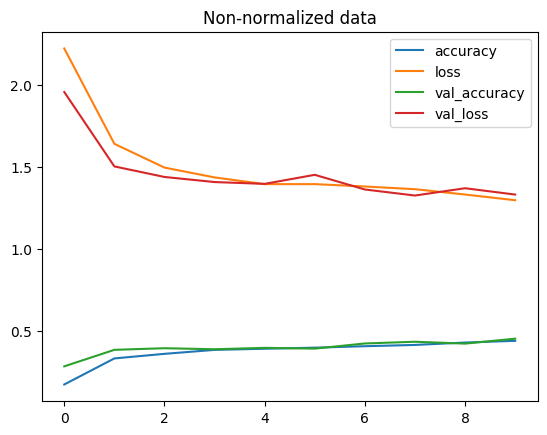

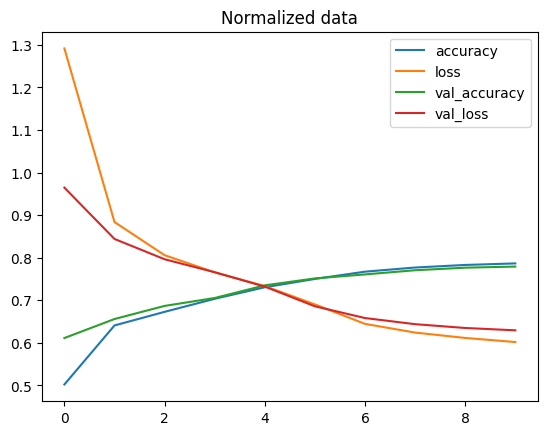

In [ ]:
pd.DataFrame(non_norm_history.history).plot(title="Non-normalized data")
pd.DataFrame(norm_history.history).plot(title="Normalized data")

Từ 2 biểu đồ này ta có thể thấy được vai trò của việc chuẩn hóa dữ ;iệu ảnh hướng tới quá trình huấn luyện mô hình nhiều như thế nào.

Bây giờ ta hãy tìm ra `learning rate` phù hợp cho quá trình xây dựng mô hình

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_12 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

# compile a mode
model_12.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                  metrics=["accuracy"])

# learning rate callback
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10**(epoch / 20))

# fit a model
lr_history = model_12.fit(train_data, train_labels, epochs=40, callbacks=[lr_schedule], validation_data=(test_data, test_labels))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3785 - loss: 1.6569 - val_accuracy: 0.6112 - val_loss: 0.9645 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6315 - loss: 0.9150 - val_accuracy: 0.6562 - val_loss: 0.8376 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6705 - loss: 0.8150 - val_accuracy: 0.6915 - val_loss: 0.7865 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7067 - loss: 0.7668 - val_accuracy: 0.7252 - val_loss: 0.7390 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7443 - loss: 0.7064 - val_accuracy: 0.7587 - val_loss: 0.6679 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7687 - loss: 0.6463 - val_accuracy: 0.7732 - val_loss: 0.6469 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7787 - 

Bây giờ ta hãy biểu đồ để xem coi `learning rate` mà ta thấy là tốt nhất cho mô hình là bao nhiêu

Text(0.5, 1.0, 'Learning Rate vs. Loss')

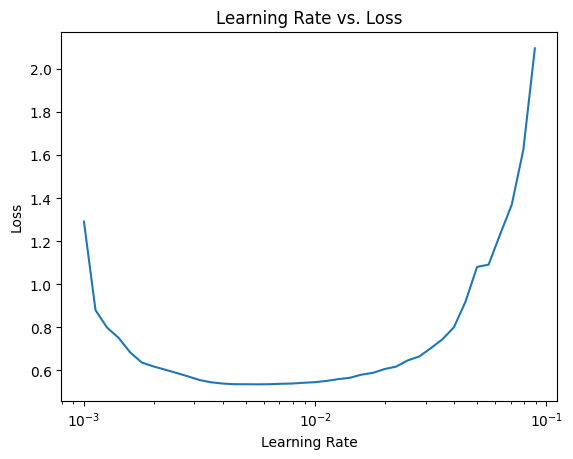

In [ ]:
lrs = 1e-3 * 10**(np.arange(40) / 20)

plt.semilogx(lrs, lr_history.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning Rate vs. Loss")

Từ biểu đồ trên ta thấy giá trị `learning rate` tốt nhất nằm đâu đó quanh 0.005 (*10^-2.3*).

Ta hãy sử dụng giá trị này cho optimizer

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_13 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

# compile a model
model_13.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.005),
                  metrics=["accuracy"])

# fit a model
model_13.fit(train_data, train_labels, epochs=20, validation_data=(test_data, test_labels))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.4006 - loss: 1.4544 - val_accuracy: 0.5704 - val_loss: 0.9880
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6114 - loss: 0.9460 - val_accuracy: 0.6209 - val_loss: 0.8796
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6753 - loss: 0.8552 - val_accuracy: 0.6955 - val_loss: 0.8157
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.7050 - loss: 0.7969 - val_accuracy: 0.7107 - val_loss: 0.7846
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7151 - loss: 0.7708 - val_accuracy: 0.7090 - val_loss: 0.7919
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7194 - loss: 0.7607 - val_accuracy: 0.7188 - val_loss: 0.7764
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7253 - loss: 0.7528 - val_accuracy: 0.7154 - val_loss: 0.7803
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7284 - loss: 0.7453 

Ta sẽ thử với 1 learning rate khác để so sánh

In [ ]:
tf.keras.utils.set_random_seed(42)

# create a model
model_14 = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(4, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

# compile a model
model_14.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=["accuracy"])

# fit a model
model_14.fit(train_data, train_labels, epochs=20, validation_data=(test_data, test_labels))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.3785 - loss: 1.6569 - val_accuracy: 0.6112 - val_loss: 0.9645
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6300 - loss: 0.9173 - val_accuracy: 0.6559 - val_loss: 0.8440
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6680 - loss: 0.8211 - val_accuracy: 0.6867 - val_loss: 0.7963
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6962 - loss: 0.7775 - val_accuracy: 0.7053 - val_loss: 0.7658
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7223 - loss: 0.7452 - val_accuracy: 0.7350 - val_loss: 0.7321
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7452 - loss: 0.7060 - val_accuracy: 0.7513 - val_loss: 0.6858
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7648 - loss: 0.6556 - val_accuracy: 0.7607 - val_loss: 0.6582
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7754 - loss: 0.6318

Có vẻ mô hình mới này của chúng ta hoạt động tốt hơn là mô hình trước, vậy nên ta sẽ sử dụng mô hình này.

Bây giờ ta sẽ có 1 số lựa chọn như sau:
- Đánh giá hiệu suất của nó bằng cách sử dụng các số liệu phân loại (*bằng confusion matrix hoặc classification report*)
- Đánh giá một số dự đoán của nó (*thông qua hình ảnh trực quan, biểu đồ*)
- Cải thiện accuracy của nó (*bằng cách đào tạo nó lâu hơn hoặc thay đổi kiến trúc*).
- Lưu mô hình và xuất nó để sử dụng trong một ứng dụng.

Trước tiên ta sẽ xem xét trước 2 lựa chọn đầu tiên.

Đầu tiên ta sẽ tạo một ma trận phân loại để trực quan hóa các dự đoán của nó trên các class khác nhau.

In [ ]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)

Vì confusion matrix so sánh các label đúng với các label dự đoán, nên ta phải đưa ra một số dự đoán bằng mô hình của mình.

In [ ]:
y_probs = model_14.predict(test_data)

y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[2.7396760e-10, 2.1248125e-10, 2.6632994e-09, 1.4358678e-06,
        3.1199587e-10, 1.3428901e-01, 6.6768352e-10, 2.0691222e-01,
        1.0685540e-03, 6.5772879e-01],
       [3.9661699e-03, 3.3279714e-05, 8.8429266e-01, 6.3728017e-04,
        6.0874052e-02, 5.2265718e-04, 3.8476374e-02, 6.6504232e-04,
        4.8825492e-05, 1.0483453e-02],
       [9.1566008e-06, 9.9843574e-01, 5.6188935e-13, 1.5550167e-03,
        1.5573254e-13, 5.1595184e-18, 1.5240381e-09, 6.9621419e-19,
        2.4378923e-13, 1.3965184e-16],
       [4.2148383e-07, 9.9800402e-01, 2.8917336e-15, 1.9955456e-03,
        6.6302053e-17, 6.4268350e-15, 7.3855652e-12, 6.2739828e-15,
        4.8339830e-12, 2.8841008e-14],
       [9.4940446e-02, 4.7460757e-04, 3.0560288e-01, 1.3004040e-02,
        1.1986166e-01, 1.2588395e-04, 4.6542123e-01, 1.0948163e-06,
        5.5302115e-04, 1.5099182e-05]], dtype=float32)

Khi dữ liệu đi qua mô hình, thứ mà ta nhận được là xác suất dự đoán 1 label class mà mô hình có thể lựa chọn cho từng instance.

Con số trong 1 danh sách xác suất dự đoán càng cao thì khả năng mô hình tin rằng đó là label class của chính instance đó càng lớn.

Và để lấy giá trị cao nhất, ta có thể sử dụng hàm `argmax()`.

Ví dụ như sau

In [ ]:
y_probs[0].argmax(), class_names[y_probs[0].argmax()]

(np.int64(9), 'Ankle boot')

Và ta sẽ làm điều này trên toàn bộ dữ liệu xác suất mà mô hình đã dự đoán

In [ ]:
y_preds = y_probs.argmax(axis=1)

y_preds[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

Rất tốt, giờ ta đã có các dự đoán của mô hình dưới dạng label, hãy tạo một confusion matrix để xem chúng so với các label thật sự

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true=test_labels, y_pred=y_preds)

array([[723,   6,  14,  79,  14,   2, 154,   0,   8,   0],
       [ 10, 931,   4,  34,   5,   0,  16,   0,   0,   0],
       [ 14,   0, 711,   9, 163,   0,  98,   0,   1,   4],
       [ 31,  25,   4, 809,  28,   1,  82,   0,  19,   1],
       [  0,   0, 158,  33, 702,   2,  84,   0,  21,   0],
       [  0,   0,   4,   0,   0, 894,   0,  67,   6,  29],
       [146,   0, 133,  52, 207,   0, 447,   0,  15,   0],
       [  0,   0,   0,   0,   0,  33,   0, 941,   0,  26],
       [  1,   0,   4,  13,  53,  13,  18,   3, 892,   3],
       [  0,   0,   0,   1,   1,  12,   2,  68,   2, 914]])

Ta có thể làm nó đẹp hơn 1 chút bằng hàm mà ta vừa tạo

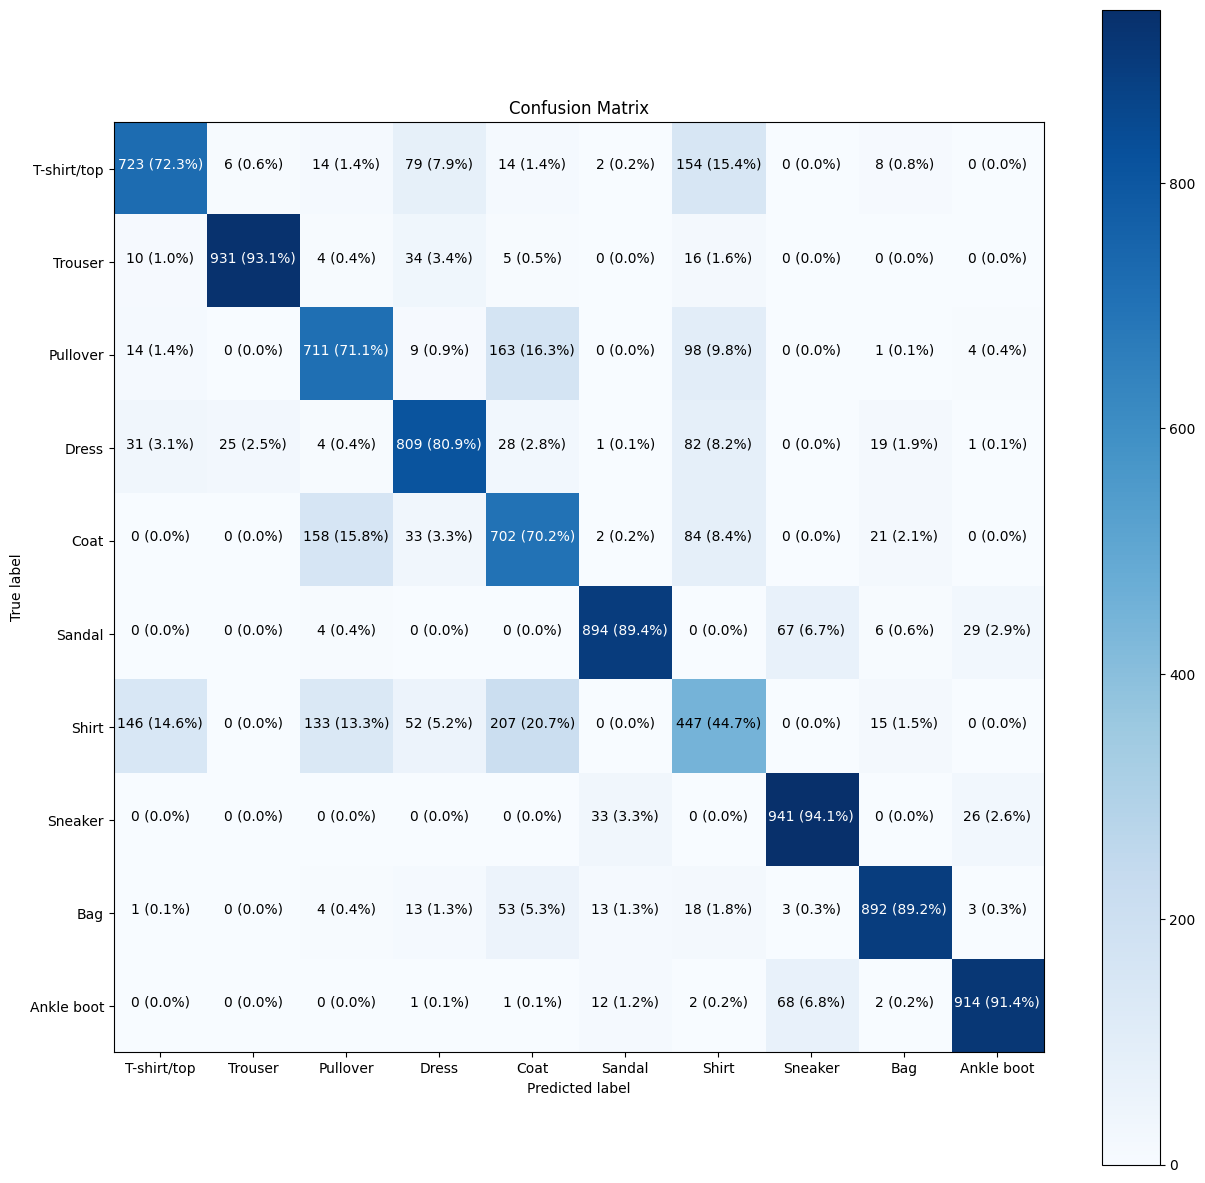

In [ ]:
make_confusion_matrix(y_true=test_labels, y_pred=y_preds, classes=class_names, figsize=(15, 15), text_size=10)

Trông nó đẹp và rõ ràng hơn rất nhiều.

Có vẻ như mô hình của ta đang bị nhầm lẫn giữa class Shirt và T-shirt/top (*ví dụ: dự đoán Shirt trong khi thực tế nó là T-shirt/top*).

> 🤔 Ta có thể đặt ra 1 câu hỏi là: lý do vì sao mô hình của chúng lại bị nhầm lẫn giữa Áo phông và áo sơ mi ? Và ta có cách nào xử lý được vấn đề này ?

Ta đã thấy các mô hình dự đoán của mình phù hợp với `true label` như thế nào khi sử dụng confusion matrix, nhưng ta hãy hình dung một số mô hình như thế nào?

Hãy tạo một hàm để vẽ một hình ảnh ngẫu nhiên cùng với dự đoán của nó.

In [ ]:
import random

def plot_random_image(model, images, true_labels, classes):
  # Setup random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28)) # have to reshape to get into right size for model
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # set the color to green or red

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


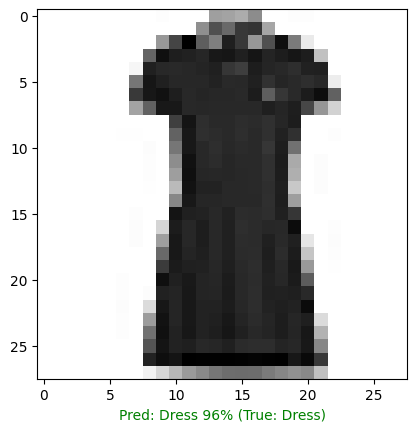

In [ ]:
plot_random_image(model=model_14,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

Sau khi chạy ô trên một vài lần, ta sẽ bắt đầu hiểu được mối quan hệ trực quan giữa dự đoán của mô hình và true label.

Ta có thể thấy, ngoài class `Shirt` và `T-shirt` ra, mô hình còn thường bị nhầm lẫn giữa class `Ankle Boot` và `Sneaker`

# Mô hình của ta đang học theo những `pattern` (*mẫu*) nào?

Ta đã nói rất nhiều lần về các pattern mà mô hình học được trong các giai đoạn của huấn luyện, nhưng nó trông như thế nào ?

Bây giờ ta sẽ bắt đầu tìm hiểu xem chúng trông ra sao.

Đầu tiên, ta lấy danh sách các layer của mô hình mà ta đã xây dựng

In [ ]:
model_14.layers

[<Flatten name=flatten_4, built=True>,
 <Dense name=dense_35, built=True>,
 <Dense name=dense_36, built=True>,
 <Dense name=dense_37, built=True>]

Ta cũng có thể truy cập vào từng layer bằng cách truyền thêm chỉ mục của chúng

In [ ]:
model_14.layers[1]

<Dense name=dense_35, built=True>

Và ta có thể tìm thấy các pattern được học bởi một layer cụ thể bằng cách sử dụng phương thức `get_weights()`.

`get_weights()` trả về **Weight** (*trọng số*) và **Bias** (*độ lệch*) của một layer cụ thể


In [ ]:
weights, biases = model_14.layers[1].get_weights()

weights, weights.shape

(array([[ 0.5392157 ,  0.05349917,  0.4404542 , -0.49600318],
        [ 0.34032136,  0.01661774,  0.20147343, -0.5481084 ],
        [ 0.4966791 , -0.63206804,  0.788554  , -1.0640401 ],
        ...,
        [ 0.5588416 ,  0.09278902, -0.17900379, -0.4051584 ],
        [-0.18254523,  0.03449054, -0.27373695,  0.23638874],
        [-0.6450158 , -0.19445395,  0.7906927 , -0.31947145]],
       dtype=float32),
 (784, 4))

**Weight** có cùng shape với dữ liệu input, trong trường hợp này là 784 (*28x28 pixel*). Và có một bản sao của ma trận trọng số cho mỗi nơ-ron trong layer đã chọn (*layer đã chọn của chúng ta có 4 nơ-ron*).

Mỗi giá trị trong ma trận trọng số tương ứng với cách một giá trị cụ thể trong dữ liệu input ảnh hưởng đến các quyết định của mạng.

Các giá trị này bắt đầu là các số ngẫu nhiên (*chúng được thiết lập bởi [tham số `kernel_initializer`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense) khi tạo một layer, mặc định là [`"glorot_uniform"`](https://www.tensorflow.org/api_docs/python/tf/keras/initializers/GlorotUniform)) và sau đó được mạng nơ-ron cập nhật thành các giá trị đại diện tốt hơn cho dữ liệu (*không ngẫu nhiên nữa*) trong quá trình đào tạo.

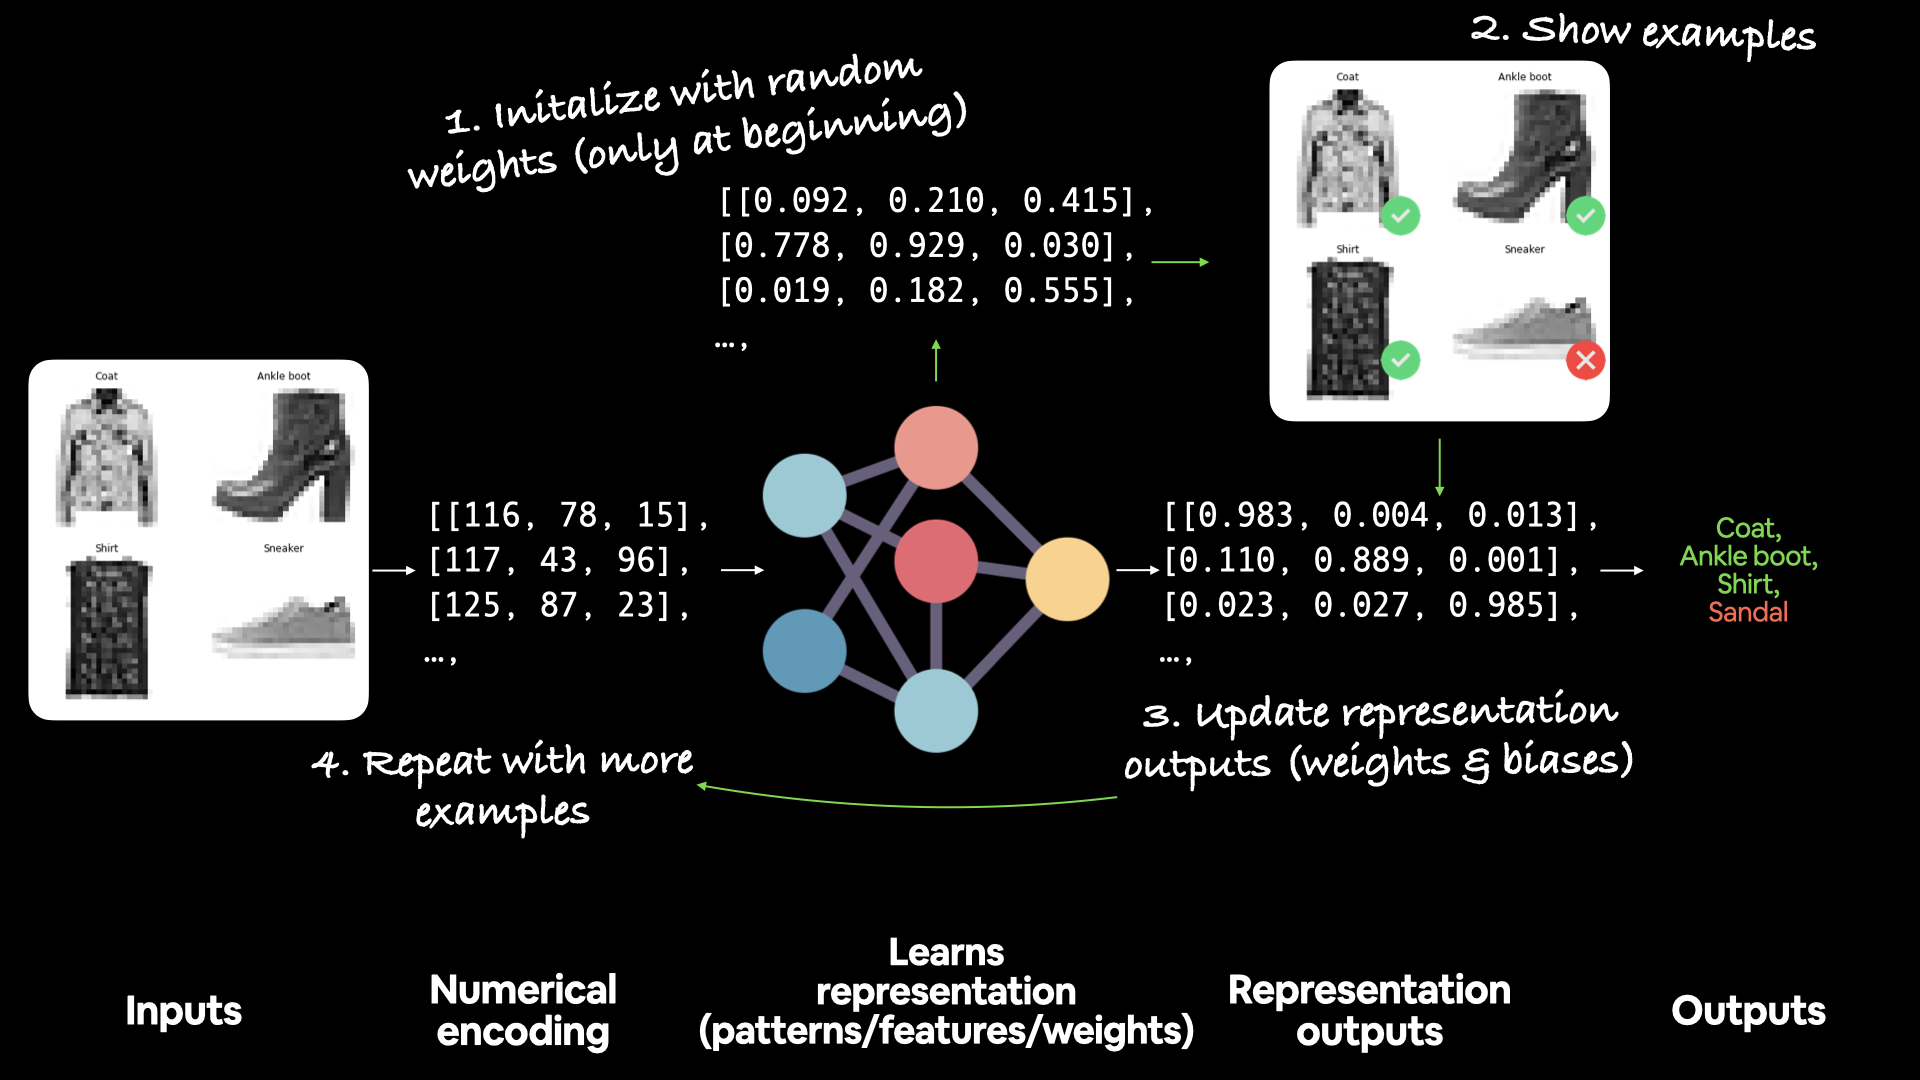

Ta cũng kiểm tra cả Bias của layer này nữa

In [ ]:
biases, biases.shape

(array([ 2.2278266 ,  1.0812196 , -0.4718026 , -0.73375684], dtype=float32),
 (4,))

Mỗi nơ-ron đều có 1 bias vector. Mỗi vector này được ghép nối với một ma trận trọng số.

Theo mặc định, các giá trị bias được khởi tạo thành số 0 (sử dụng [tham số `bias_initializer`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense))

Bias vector quyết định mức độ các pattern trong ma trận trọng số tương ứng sẽ ảnh hưởng đến layer tiếp theo.

In [ ]:
model_14.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 4)              │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,632 (37.63 KB)

 Trainable params: 3,210 (12.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,422 (25.09 KB)

Bây giờ ta đã xây dựng được một số mô hình deep learning, đã đến lúc chỉ ra toàn bộ khái niệm về input và output không chỉ liên quan đến toàn bộ mô hình mà còn liên quan đến từng layer trong mô hình đó

Bắt đầu từ input layer, input của mỗi layer tiếp theo chính là output của layer trước đó.

Ta có thể thấy rõ điều này bằng cách sử dụng hàm tiện ích `plot_model()`.

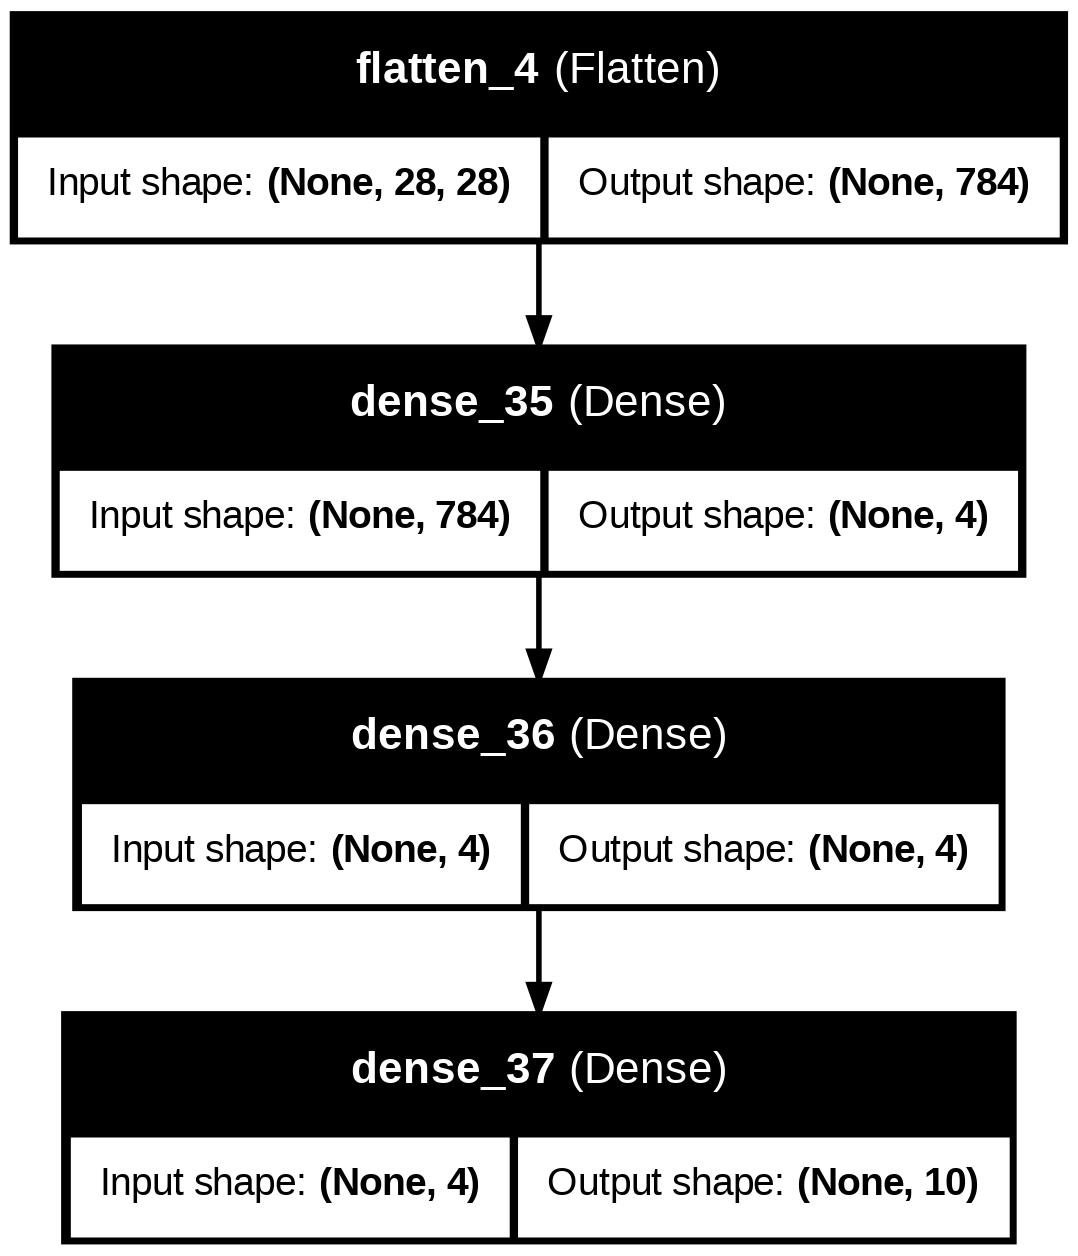

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model_14, show_shapes=True, show_layer_names=True)

# Tóm tắt Cách một mô hình học
Ta đã huấn luyện một loạt mô hình, nhưng chưa bao giờ thực sự thảo luận về những gì đang diễn ra bên trong. Vậy chính xác thì một mô hình học như thế nào?

Một mô hình học bằng cách cập nhật và cải thiện các ma trận weight và giá trị bias của nó sau mỗi epoch (*khi ta gọi tới hàm `fit()`*).

Nó thực hiện điều này bằng cách so sánh các pattern đã học được giữa data và label với các label thực tế.

Nếu các pattern hiện tại (*ma trận weight và giá trị bias*) không dẫn đến sự giảm mà ta mong muốn trong `loss function` (*loss cao hơn có nghĩa là dự đoán tệ hơn*), `optimizer` hóa sẽ cố gắng điều khiển mô hình để cập nhật các pattern theo đúng cách (*sử dụng label thực tế làm tham chiếu*).

Quá trình sử dụng label thực tế làm tham chiếu để cải thiện dự đoán của mô hình được gọi là [**Backpropagation** (*truyền ngược*)](https://en.wikipedia.org/wiki/Backpropagation).

Nói cách khác, data và label sẽ đi qua một mô hình (*forward pass*) và mô hình sẽ cố gắng tìm hiểu mối quan hệ giữa data và label

Và nếu mối quan hệ đã học này không gần với mối quan hệ thực tế hoặc có thể được cải thiện, mô hình sẽ thực hiện bằng cách quay lại chính nó (*backward pass*) và điều chỉnh ma trận weight và giá trị bias để biểu diễn dữ liệu tốt hơn.

# Tài liệu thêm
1. Xem thêm video về [mạng neauron là gì](https://www.youtube.com/watch?v=aircAruvnKk)
2. Xem video về mạng nơ-ron của 3Blue1Brown: [Gradient descent, cách mạng nơ-ron học](https://www.youtube.com/watch?v=IHZwWFHWa-w).
3. Xem [bài giảng giới thiệu về học sâu số 1 của MIT](https://www.youtube.com/watch?v=njKP3FqW3Sk) để hiểu rõ hơn về các khái niệm sử dụng hàm tuyến tính và hàm phi tuyến tính.
4. Đọc thêm [Cuốn sách Mạng nơ-ron và học sâu của Michael Nielsen](http://neuralnetworksanddeeplearning.com/index.html)
5. Đọc tài liệu [ML-Glossary về các activation function](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html).
  - Tìm hiểu thêm về các activation function có trong tensorflow